<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/One_Way_ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Mastering One-Way ANOVA: Analysis & Visualization in R**

### নোটবুক পরিচিতি (Metadata)

* **Aim:** এই গাইডের লক্ষ্য হলো `ToothGrowth` ডাটাসেট ব্যবহার করে স্ট্যাটিস্টিক্যাল সিগনিফিকেন্স পরীক্ষা করা এবং প্রফেশনাল বার চার্টে **CLD (Compact Letter Display)** যোগ করা।
* **Concept:** আমরা দেখব কীভাবে বিভিন্ন ডোজের প্রভাবে দাঁতের বৃদ্ধির পার্থক্য গাণিতিকভাবে প্রমাণ করা যায় এবং তা গ্রাফে ফুটিয়ে তোলা যায়।
* **Key Skills:** ANOVA Test, Tukey's Post-hoc Test, Error Bars, এবং CLD Labeling।

---

## কেন One-Way ANOVA এবং CLD গুরুত্বপূর্ণ?

- ১. **পার্থক্য নির্ণয়:** দুইয়ের অধিক গ্রুপের মধ্যে গড়ের পার্থক্য কি কাকতালীয় নাকি বাস্তব, তা ANOVA দিয়ে বোঝা যায়।
- ২. **পোস্ট-হক টেস্ট:** ANOVA শুধু বলে "পার্থক্য আছে", কিন্তু Tukey Test বলে ঠিক "কোন গ্রুপগুলোর মধ্যে" পার্থক্য আছে।
- ৩. **CLD লেটার:** গ্রাফের ওপর 'a', 'b', বা 'ab' লেটার দেখে সহজেই বোঝা যায় কোন গ্রুপগুলো একে অপরের থেকে আলাদা।

---

## ১. এনভায়রনমেন্ট সেটআপ (Setup)

প্রথমে প্রয়োজনীয় প্যাকেজ এবং ডাটাসেট লোড করে ডোজ (Dose) কলামটিকে ফ্যাক্টরে রূপান্তর করতে হবে।

In [ ]:
install.packages('multcompView')
install.packages('emmeans')

# ১. প্রয়োজনীয় প্যাকেজ লোড
library(tidyverse)
library(multcompView)
library(emmeans)  # পোস্ট-হক টেস্টের জন্য

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [ ]:
# ২. ডেটা প্রস্তুত করুন
data(ToothGrowth)
ToothGrowth$dose <- as.factor(ToothGrowth$dose) # ডোজকে ক্যাটাগরিক্যাল ফ্যাক্টরে রূপান্তর

## ২. স্ট্যাটিস্টিক্যাল বিশ্লেষণ (Statistical Analysis)

### ধাপ ১: ANOVA রান করা

আমরা দেখব ভিটামিন সি-এর ডোজের পরিবর্তনের সাথে দাঁতের দৈর্ঘ্যের কোনো সম্পর্ক আছে কি না।

In [ ]:
# ৩. ওয়ান-ওয়ে ANOVA বিশ্লেষণ
anova_result <- aov(len ~ dose, data = ToothGrowth)
summary(anova_result)

# প্রো-টিপ: পাইপ অপারেটর দিয়েও এটি করা যায়
# ToothGrowth %>% aov(len ~ dose, data = .) %>% summary()

            Df Sum Sq Mean Sq F value   Pr(>F)    
dose         2   2426    1213   67.42 9.53e-16 ***
Residuals   57   1026      18                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### ধাপ ২: টুকি টেস্ট ও CLD তৈরি

ANOVA পজিটিভ হলে আমরা **Tukey HSD** টেস্ট করি এবং গ্রুপগুলোর মধ্যে সম্পর্কের ভিত্তিতে লেটার (Letters) বরাদ্দ করি।


In [ ]:
# ৪. টুকি টেস্ট ও CLD তৈরি
tukey_result <- TukeyHSD(anova_result)

# গ্রুপগুলোকে আলাদা করার জন্য লেটার তৈরি (যেমন: a, b, c)
cld_letters <- multcompLetters4(anova_result, tukey_result)
print(cld_letters)

$dose
  2   1 0.5 
"a" "b" "c" 



## ৩. ডেটা সামারি এবং ভিজ্যুয়ালাইজেশন (Visualization)

গ্রাফ তৈরির আগে আমাদের প্রতিটি গ্রুপের গড় (Mean) এবং স্ট্যান্ডার্ড ডেভিয়েশন (SD) বের করে নিতে হবে।

In [ ]:
# ৫. গ্রুপের গড় ও CLD লেটার একত্রিত করা
summary_data <- ToothGrowth %>%
  group_by(dose) %>%
  summarise(
    mean_len = mean(len),
    sd_len = sd(len)
  ) %>%
  mutate(
    cld = cld_letters$dose$Letters  # CLD লেটার যোগ
  )

### প্রফেশনাল বার গ্রাফ তৈরি

এখন আমরা গড় মানের বার, এরর বার এবং স্ট্যাটিস্টিক্যাল লেটারগুলো একটি প্লটে সাজাব।

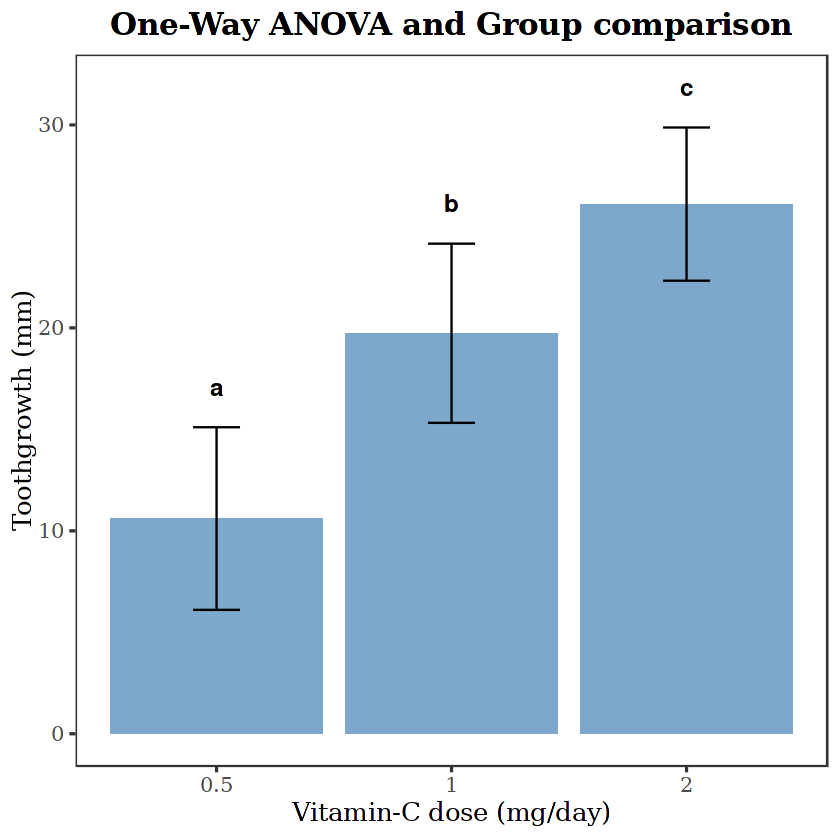

In [ ]:
# ৬. বার গ্রাফ তৈরি (CLD সহ)
summary_data %>%
  ggplot(aes(dose, mean_len)) +
  geom_bar(stat = "identity", fill = "steelblue", alpha = 0.7) +
  # এরর বার যোগ (Standard Deviation)
  geom_errorbar(aes(ymin = mean_len - sd_len, ymax = mean_len + sd_len),
                width = 0.2, color = "black") +
  # স্ট্যাটিস্টিক্যাল লেটার (CLD) যোগ
  geom_text(aes(label = cld, y = mean_len + sd_len + 2),
            size = 5, color = "black", fontface = "bold") +
  labs(x = "Vitamin-C dose (mg/day)",
       y = "Toothgrowth (mm)",
       title = "One-Way ANOVA and Group comparison") +
  theme_test(base_size = 15, base_family = "serif") +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

---

## এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):

* **`aov()`**: ওয়ান-ওয়ে অ্যানোভা টেস্ট করার প্রধান ফাংশন।
* **`TukeyHSD()`**: গ্রুপগুলোর মধ্যে জোড়ায় জোড়ায় পার্থক্যের সিগনিফিকেন্স দেখা।
* **`multcompLetters4()`**: স্ট্যাটিস্টিক্যাল পার্থক্যের ভিত্তিতে সহজবোধ্য লেটার কোড তৈরি।
* **`geom_errorbar()`**: ডেটার ভিন্নতা বা ভ্যারিয়েশন দেখানোর জন্য অত্যাবশ্যক।

---